In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
test = pd.read_csv('Smart-Warehouse-Delay/data/test_v2.csv')
test

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,TEST_000000,WH_202,SC_10973,61.0,155.0,NaN,0.0000,0.0656,0.1311,0.3047,...,6.0,13.0,0.5969,0.3042,44,25,3154,14.1,24,10
1,TEST_000001,WH_202,SC_10973,59.0,108.0,NaN,NaN,0.0847,0.0847,0.3047,...,6.0,13.0,0.5969,0.3042,44,25,3154,14.1,24,10
2,TEST_000002,WH_202,SC_10973,95.0,200.0,3.35,0.0526,NaN,0.1053,0.3047,...,6.0,13.0,0.5969,0.3042,44,25,3154,14.1,24,10
3,TEST_000003,WH_202,SC_10973,59.0,166.0,4.20,0.0339,0.0508,0.1017,0.3047,...,6.0,13.0,0.5969,0.3042,44,25,3154,14.1,24,10
4,TEST_000004,WH_202,SC_10973,NaN,130.0,NaN,0.0200,0.0200,0.1000,0.3047,...,6.0,13.0,0.5969,0.3042,44,25,3154,14.1,24,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TEST_049995,WH_225,SC_10910,13.0,9.0,1.31,0.0000,0.0000,0.0000,NaN,...,3.0,8.0,0.7574,0.2240,18,39,2255,14.8,53,3
49996,TEST_049996,WH_225,SC_10910,NaN,NaN,1.00,0.0000,0.3333,0.0000,0.2150,...,3.0,8.0,0.7574,0.2240,18,39,2255,14.8,53,3
49997,TEST_049997,WH_225,SC_10910,10.0,NaN,2.10,NaN,0.0000,0.0000,0.2150,...,3.0,8.0,0.7574,0.2240,18,39,2255,14.8,53,3
49998,TEST_049998,WH_225,SC_10910,17.0,15.0,NaN,NaN,0.2353,0.0000,0.2150,...,3.0,8.0,0.7574,0.2240,18,39,2255,14.8,53,3


#
### **🔋 3. 배터리 & 충전 (Battery)**
* battery_mean → 평균 배터리 잔량
* battery_std → 배터리 잔량 편차
* low_battery_ratio → 배터리 부족 로봇 비율
* charge_queue_length → 충전 대기 줄 길이
* avg_charge_wait → 평균 충전 대기 시간
* charge_efficiency_pct → 충전 효율
* battery_cycle_count_avg → 평균 충전 사이클 수

layout_info.csv
* charger_count → 충전기 개수

In [ ]:
test_battery = test[["battery_mean","battery_std","low_battery_ratio",
        "charge_queue_length","avg_charge_wait","charge_efficiency_pct",
        "battery_cycle_count_avg","charger_count"]]
test_battery

,battery_mean,battery_std,low_battery_ratio,charge_queue_length,avg_charge_wait,charge_efficiency_pct,battery_cycle_count_avg,charger_count
0,NaN,NaN,0.0000,0.0,0.0,91.0,98.0,13.0
1,66.59,17.45,0.0000,0.0,0.0,94.8,80.0,13.0
2,63.92,17.56,0.0000,0.0,0.0,98.5,61.0,13.0
3,61.89,17.29,0.0000,0.0,0.0,88.7,81.0,13.0
4,60.12,17.36,0.0227,0.0,0.0,89.2,50.0,13.0
...,...,...,...,...,...,...,...,...
49995,48.96,16.71,0.0556,0.0,NaN,80.0,85.0,8.0
49996,48.94,15.78,0.0000,0.0,0.0,81.2,82.0,8.0
49997,48.41,NaN,0.0556,NaN,0.0,85.5,119.0,8.0
49998,49.34,15.53,0.0000,0.0,NaN,83.8,NaN,8.0


###
### **결측치 채우기**
#### test datasets
① battery_mean ↔ low_battery_ratio = **-0.93**

In [ ]:
test_battery[["battery_mean", "low_battery_ratio"]]

,battery_mean,low_battery_ratio
0,NaN,0.0000
1,66.59,0.0000
2,63.92,0.0000
3,61.89,0.0000
4,60.12,0.0227
...,...,...
49995,48.96,0.0556
49996,48.94,0.0000
49997,48.41,0.0556
49998,49.34,0.0000


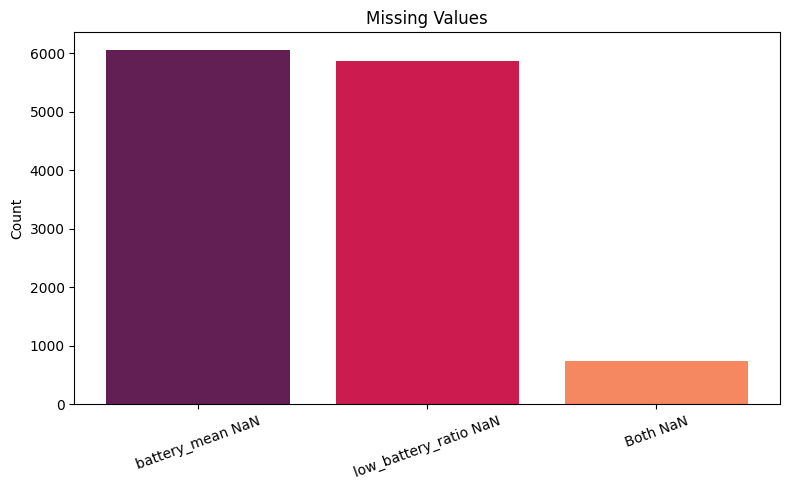

In [ ]:
# 각각 결측치 개수
battery_mean_na = test_battery["battery_mean"].isnull().sum()
low_ratio_na = test_battery["low_battery_ratio"].isnull().sum()

# 둘 다 결측치인 경우
both_na = (
    test_battery["battery_mean"].isnull() &
    test_battery["low_battery_ratio"].isnull()
).sum()

nan_counts = {
    "battery_mean NaN": battery_mean_na,
    "low_battery_ratio NaN": low_ratio_na,
    "Both NaN": both_na
}

colors = sns.color_palette("rocket", len(nan_counts))

plt.figure(figsize=(8,5))
plt.bar(nan_counts.keys(), nan_counts.values(), color=colors)

plt.title("Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#####
* low_battery_ratio 기준 결측치 **"battery_mean"** 채우기

In [ ]:
test_battery["battery_mean"] = test_battery["battery_mean"].fillna(
    (1 - test_battery["low_battery_ratio"]) * 100
)

In [ ]:
cols = ["battery_mean", "low_battery_ratio"]

nan_df = test_battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    test_battery["battery_mean"].isna() &
    test_battery["low_battery_ratio"].isna()
).sum()

nan_df

,Missing Values,Both Missing
battery_mean,731,731
low_battery_ratio,5857,731


#####
* battery_mean 기준 결측치 **"low_battery_ratio"** 채우기

In [ ]:
test_battery["low_battery_ratio"] = test_battery["low_battery_ratio"].fillna(
    1 - (test_battery["battery_mean"] / 100)
)

In [ ]:
cols = ["battery_mean", "low_battery_ratio"]

nan_df = test_battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    test_battery["battery_mean"].isna() &
    test_battery["low_battery_ratio"].isna()
).sum()

nan_df

,Missing Values,Both Missing
battery_mean,731,731
low_battery_ratio,731,731


##### 저장

In [ ]:
test["battery_mean"] = test_battery["battery_mean"]
test["low_battery_ratio"] = test_battery["low_battery_ratio"]

In [ ]:
test[["battery_mean", "low_battery_ratio"]].isnull().sum().to_frame(name="NaN")

,NaN
battery_mean,731
low_battery_ratio,731


In [ ]:
# test.to_csv("test_battery_V2.csv", index=False)

###
② charge_queue_length ↔ avg_charge_wait = **0.86**

In [ ]:
test_battery[["avg_charge_wait", "charge_queue_length"]]

,avg_charge_wait,charge_queue_length
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
49995,NaN,0.0
49996,0.0,0.0
49997,0.0,NaN
49998,NaN,0.0


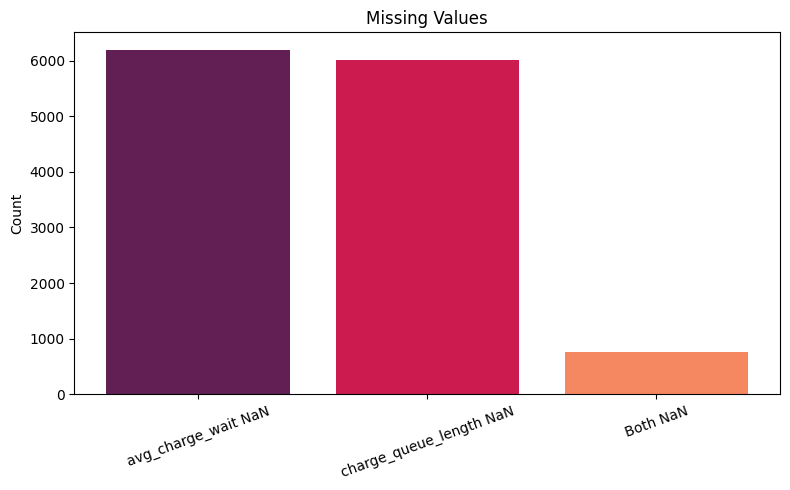

In [ ]:
# 각각 결측치 개수
wait_na = test_battery["avg_charge_wait"].isnull().sum()
queue_na = test_battery["charge_queue_length"].isnull().sum()

# 둘 다 결측치인 경우
both_na = test_battery[
    test_battery["avg_charge_wait"].isnull() &
    test_battery["charge_queue_length"].isnull()
].shape[0]

nan_counts = {
    "avg_charge_wait NaN": wait_na,
    "charge_queue_length NaN": queue_na,
    "Both NaN": both_na
}

plt.figure(figsize=(8,5))
plt.bar(nan_counts.keys(), nan_counts.values(), color=colors)

plt.title("Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#####
* charge_queue_length 기준 결측치 **"avg_charge_wait"** 채우기

In [ ]:
test_battery["avg_charge_wait"] = test_battery["avg_charge_wait"].fillna(
    test_battery["charge_queue_length"]
)

In [ ]:
cols = ["avg_charge_wait", "charge_queue_length"]

nan_df = test_battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    test_battery["avg_charge_wait"].isna() &
    test_battery["charge_queue_length"].isna()
).sum()

nan_df

,Missing Values,Both Missing
avg_charge_wait,762,762
charge_queue_length,6004,762


#####
* avg_charge_wait 기준 결측치 **"charge_queue_length"** 채우기  

In [ ]:
test_battery["charge_queue_length"] = test_battery["charge_queue_length"].fillna(
    test_battery["avg_charge_wait"]
)

In [ ]:
cols = ["avg_charge_wait", "charge_queue_length"]

nan_df = test_battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    test_battery["avg_charge_wait"].isna() &
    test_battery["charge_queue_length"].isna()
).sum()

nan_df

,Missing Values,Both Missing
avg_charge_wait,762,762
charge_queue_length,762,762


* 저장

In [ ]:
test["avg_charge_wait"] = test_battery["avg_charge_wait"]
test["charge_queue_length"] = test_battery["charge_queue_length"]

In [ ]:
test[["avg_charge_wait", "charge_queue_length"]].isnull().sum().to_frame(name="NaN")

,NaN
avg_charge_wait,762
charge_queue_length,762


In [ ]:
# test.to_csv("test_battery_V3.csv", index=False)

###
③ low_battery_ratio ↔ charge_queue_length = **0.79**  
low_battery_ratio ↔ avg_charge_wait = **0.78**

In [ ]:
test_battery[["low_battery_ratio", "avg_charge_wait","charge_queue_length"]]

,low_battery_ratio,avg_charge_wait,charge_queue_length
0,0.0000,0.0,0.0
1,0.0000,0.0,0.0
2,0.0000,0.0,0.0
3,0.0000,0.0,0.0
4,0.0227,0.0,0.0
...,...,...,...
49995,0.0556,0.0,0.0
49996,0.0000,0.0,0.0
49997,0.0556,0.0,0.0
49998,0.0000,0.0,0.0


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

cols = ["low_battery_ratio", "charge_queue_length", "avg_charge_wait"]

# 스케일링
scaler = StandardScaler()
scaled_data = scaler.fit_transform(test_battery[cols])

# KNN Imputer 적용
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(scaled_data)

# 원래 스케일로 복원
battery_imputed = pd.DataFrame(
    scaler.inverse_transform(imputed_data),
    columns=cols,
    index=test_battery.index
)

# 원본 데이터에 반영
test_battery[cols] = battery_imputed

In [ ]:
test["low_battery_ratio"] = test_battery["low_battery_ratio"]
test["charge_queue_length"] = test_battery["charge_queue_length"]
test["avg_charge_wait"] = test_battery["avg_charge_wait"]

In [ ]:
test[["low_battery_ratio", "avg_charge_wait", "charge_queue_length"]].isnull().sum().to_frame(name="NaN")

,NaN
low_battery_ratio,0
avg_charge_wait,0
charge_queue_length,0


In [ ]:
# test.to_csv("test_battery_V5.csv", index=False)

#####
* test_battery_V5에 layout_info 컬럼들 추가

In [ ]:
_battery = pd.read_csv('Smart-Warehouse-Delay/data/test_battery_V5.csv')
_battery

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TEST_000000,WH_202,SC_10973,61.0,155.0,NaN,0.0000,0.0656,0.1311,0.3047,...,4.88,0.0534,4.93,0.2164,13.5,NaN,96.2,0.0374,0.00,97.74
1,TEST_000001,WH_202,SC_10973,59.0,108.0,NaN,NaN,0.0847,0.0847,0.3047,...,6.69,NaN,NaN,NaN,21.1,15.94,90.5,0.0522,3.03,NaN
2,TEST_000002,WH_202,SC_10973,95.0,200.0,3.35,0.0526,NaN,0.1053,0.3047,...,6.28,0.0534,8.57,0.2292,23.2,16.25,NaN,0.0649,1.36,95.31
3,TEST_000003,WH_202,SC_10973,59.0,166.0,4.20,0.0339,0.0508,0.1017,0.3047,...,7.92,0.0835,NaN,0.2045,NaN,15.57,NaN,0.0268,0.64,94.01
4,TEST_000004,WH_202,SC_10973,NaN,130.0,NaN,0.0200,0.0200,0.1000,0.3047,...,7.00,0.1684,NaN,0.2174,NaN,17.16,91.0,0.0533,0.25,95.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TEST_049995,WH_225,SC_10910,13.0,9.0,1.31,0.0000,0.0000,0.0000,NaN,...,4.59,0.2267,8.26,0.0450,18.3,NaN,84.8,NaN,NaN,95.08
49996,TEST_049996,WH_225,SC_10910,NaN,NaN,1.00,0.0000,0.3333,0.0000,0.2150,...,4.80,0.1775,6.18,0.0305,9.6,9.82,83.0,0.1309,9.64,94.56
49997,TEST_049997,WH_225,SC_10910,10.0,NaN,2.10,NaN,0.0000,0.0000,0.2150,...,5.71,0.2488,6.52,0.0536,9.4,NaN,86.9,0.1206,9.75,96.14
49998,TEST_049998,WH_225,SC_10910,17.0,15.0,NaN,NaN,0.2353,0.0000,0.2150,...,5.15,NaN,9.41,0.0881,20.1,12.96,81.9,0.1228,8.09,NaN


In [ ]:
layout = pd.read_csv('Smart-Warehouse-Delay/data/layout_info.csv')
layout

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2
3,WH_004,hybrid,3.37,35.0,0.4836,5.0,10.0,0.4821,0.5661,100,40,7918,12.7,26,5
4,WH_005,grid,3.68,48.0,0.0494,8.0,13.0,0.6740,0.9970,50,33,5905,5.6,84,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,WH_296,grid,3.26,45.0,0.2777,7.0,7.0,0.7694,0.7045,19,35,4080,10.9,22,9
296,WH_297,hybrid,2.14,25.0,0.1410,19.0,15.0,0.5534,0.1224,30,20,8782,12.2,58,2
297,WH_298,hub_spoke,3.74,10.0,0.0107,4.0,10.0,0.3098,0.4970,26,17,6635,9.6,91,6
298,WH_299,narrow,1.70,15.0,0.6002,9.0,15.0,0.8984,0.9239,58,33,3744,14.7,83,3


In [ ]:
_battery = _battery.merge(layout, on="layout_id", how="left")

In [ ]:
_battery.to_csv("test_battery_V6.csv", index=False)